In [37]:
import pandas as pd

data = pd.read_csv("SuperMarket Sales Dataset.csv")

data.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [38]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [39]:
data['Date'] = pd.to_datetime(data['Date'])


In [40]:
data['Date'].head()

0   2019-01-05
1   2019-03-08
2   2019-03-03
3   2019-01-27
4   2019-02-08
Name: Date, dtype: datetime64[us]

In [41]:
data['Day'] = data['Date'].dt.day
data['Month'] = data['Date'].dt.month
data['DayOfWeek'] = data['Date'].dt.dayofweek

In [42]:
data[['Date','Day','Month','DayOfWeek']].head()

,Date,Day,Month,DayOfWeek
0,2019-01-05,5,1,5
1,2019-03-08,8,3,4
2,2019-03-03,3,3,6
3,2019-01-27,27,1,6
4,2019-02-08,8,2,4


In [43]:
data_encoded = pd.get_dummies(data, columns=[
    'Branch',
    'City',
    'Customer type',
    'Gender',
    'Product line',
    'Payment'
])

In [44]:
data_encoded.shape


(1000, 33)

In [45]:
X = data_encoded.drop(columns=['Quantity','Invoice ID','Date','Time'])
y = data_encoded['Quantity']

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    
)

In [47]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [48]:
from sklearn.metrics import r2_score, mean_absolute_error

predictions = model.predict(X_test)

print("R2 Score:", r2_score(y_test, predictions))
print("MAE:", mean_absolute_error(y_test, predictions))

R2 Score: 0.9914768257143681
MAE: 0.17285


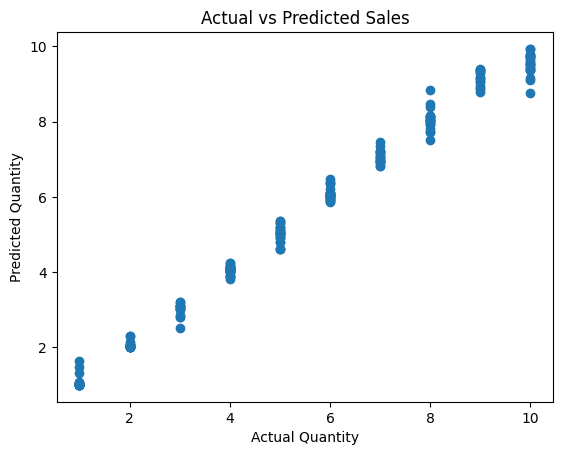

In [49]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual Quantity")
plt.ylabel("Predicted Quantity")
plt.title("Actual vs Predicted Sales")
plt.show()

In [50]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)

feature_importance.sort_values(ascending=False).head(10)

Unit price             0.297898
Sales                  0.200150
gross income           0.177219
Tax 5%                 0.163619
cogs                   0.151477
Rating                 0.002302
Day                    0.001769
DayOfWeek              0.000855
Month                  0.000702
Payment_Credit card    0.000338
dtype: float64

In [51]:
daily_sales = data.groupby(["Date","Product line"])["Quantity"].sum().reset_index()

daily_sales.head()

,Date,Product line,Quantity
0,2019-01-01,Electronic accessories,18
1,2019-01-01,Fashion accessories,9
2,2019-01-01,Food and beverages,18
3,2019-01-01,Health and beauty,2
4,2019-01-01,Home and lifestyle,8


In [52]:
avg_daily_sales = daily_sales.groupby("Product line")["Quantity"].mean()

avg_daily_sales

Product line
Electronic accessories    12.946667
Fashion accessories       11.714286
Food and beverages        12.526316
Health and beauty         11.698630
Home and lifestyle        12.146667
Sports and travel         11.794872
Name: Quantity, dtype: float64

In [53]:
current_stock = {
    "Electronic accessories": 120,
    "Fashion accessories": 40,
    "Food and beverages": 200,
    "Health and beauty": 60,
    "Home and lifestyle": 80,
    "Sports and travel": 50
}

results = []

for product in avg_daily_sales.index:
    
    stock = current_stock[product]
    daily = avg_daily_sales[product]
    
    coverage = stock / daily
    
    if coverage > 60:
        status = "Overstock Risk"
    elif coverage < 15:
        status = "Stockout Risk"
    else:
        status = "Healthy Inventory"
    
    results.append([product, stock, daily, coverage, status])

health_df = pd.DataFrame(
    results,
    columns=["Product","Stock","Avg Daily Sales","Coverage Days","Status"]
)

health_df

,Product,Stock,Avg Daily Sales,Coverage Days,Status
0,Electronic accessories,120,12.946667,9.268795,Stockout Risk
1,Fashion accessories,40,11.714286,3.414634,Stockout Risk
2,Food and beverages,200,12.526316,15.966387,Healthy Inventory
3,Health and beauty,60,11.698630,5.128806,Stockout Risk
4,Home and lifestyle,80,12.146667,6.586169,Stockout Risk
5,Sports and travel,50,11.794872,4.239130,Stockout Risk


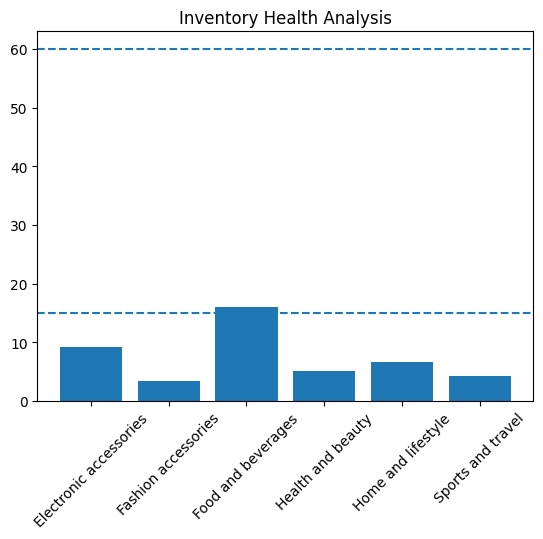

In [54]:
import matplotlib.pyplot as plt

plt.bar(health_df["Product"], health_df["Coverage Days"])
plt.xticks(rotation=45)

plt.axhline(15, linestyle="--")
plt.axhline(60, linestyle="--")

plt.title("Inventory Health Analysis")

plt.show()